# Implémentation d’une régression logistique en Python

## Objectif du projet

L’objectif de ce notebook est d’implémenter depuis zéro un modèle de régression logistique pour résoudre un problème de classification binaire.

Le cas étudié est la prédiction de l’admission universitaire d’un étudiant à partir de trois variables :

- la note obtenue à un test ;
- le taux de réussite au lycée ;
- la participation ou non à une activité extra-scolaire.

 Les différentes étapes du modèle sont : fonction sigmoïde, fonction de coût, descente de gradient, prédiction et évaluation.

## 1. Importation des bibliothèques

Les bibliothèques utilisées servent uniquement à manipuler les données, effectuer les calculs numériques et produire les graphiques.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
from IPython.display import display

## 2. Création du jeu de données

Le jeu de données utilisé est artificiel, ce qui permet de contrôler entièrement l’expérience. Il décrit des étudiants à partir de trois variables explicatives. La variable cible indique si l’étudiant est admis ou non : elle vaut 1 en cas d’admission et 0 dans le cas contraire.

La probabilité d’admission est calculée à partir d’une combinaison de ces trois variables, puis elle est transformée avec une fonction sigmoïde. Cela correspond au principe de la régression logistique, puisque l’objectif est de prédire une classe binaire.


In [2]:
def create_admission_dataset(n_samples=300, random_state=42):
    """
    Crée un jeu de données artificiel pour un problème d'admission universitaire.

    Paramètres :
    n_samples : int
        Nombre d'étudiants à générer.
    random_state : int
        Graine aléatoire utilisée pour obtenir des résultats reproductibles.

    Retour :
    pandas.DataFrame
        Tableau contenant les variables explicatives et la variable cible.
    """

    rng = np.random.default_rng(random_state)

    note_test = rng.normal(loc=65, scale=15, size=n_samples)
    note_test = np.clip(note_test, 0, 100)

    taux_lycee = rng.normal(loc=70, scale=12, size=n_samples)
    taux_lycee = np.clip(taux_lycee, 0, 100)

    extrasco = rng.binomial(n=1, p=0.45, size=n_samples)

    score = -8 + 0.05 * note_test + 0.06 * taux_lycee + 0.8 * extrasco
    probabilite_admission = 1 / (1 + np.exp(-score))

    admission = rng.binomial(n=1, p=probabilite_admission)

    data = pd.DataFrame({
        "note_test": note_test,
        "taux_lycee": taux_lycee,
        "extrasco": extrasco,
        "admission": admission
    })

    return data


df = create_admission_dataset()
df.to_csv("admission_universitaire.csv", index=False)
df.head()

,note_test,taux_lycee,extrasco,admission
0,69.570756,90.728203,0,1
1,49.400238,51.593663,1,0
2,76.256768,80.365936,0,0
3,79.108471,66.057697,1,1
4,35.734472,69.264108,1,0


## 3. Exploration rapide des données

Cette étape permet de vérifier la taille du jeu de données, les premières lignes, les statistiques descriptives et la répartition de la variable cible.

In [3]:
print("Dimensions du jeu de données :", df.shape)
print("\nPremières lignes :")
display(df.head())

print("\nStatistiques descriptives :")
display(df.describe())

print("\nRépartition de la variable cible :")
display(df["admission"].value_counts().sort_index())

Dimensions du jeu de données : (300, 4)

Premières lignes :


,note_test,taux_lycee,extrasco,admission
0,69.570756,90.728203,0,1
1,49.400238,51.593663,1,0
2,76.256768,80.365936,0,0
3,79.108471,66.057697,1,1
4,35.734472,69.264108,1,0



Statistiques descriptives :


,note_test,taux_lycee,extrasco,admission
count,300.000000,300.000000,300.000000,300.000000
mean,64.316996,69.861071,0.443333,0.466667
std,13.762668,12.191899,0.497609,0.499721
min,26.500123,34.425654,0.000000,0.000000
25%,54.959530,61.499500,0.000000,0.000000
50%,63.695144,70.725396,0.000000,0.000000
75%,72.105346,78.120795,1.000000,1.000000
max,100.000000,100.000000,1.000000,1.000000



Répartition de la variable cible :


,count
admission,
0,160
1,140


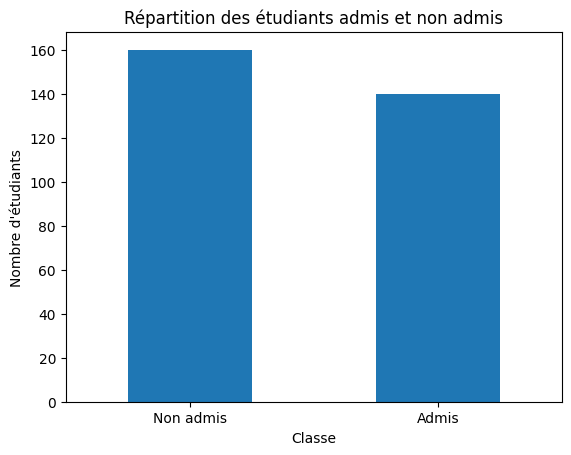

In [4]:
df["admission"].value_counts().sort_index().plot(kind="bar")
plt.xlabel("Classe")
plt.ylabel("Nombre d'étudiants")
plt.title("Répartition des étudiants admis et non admis")
plt.xticks([0, 1], ["Non admis", "Admis"], rotation=0)
plt.show()

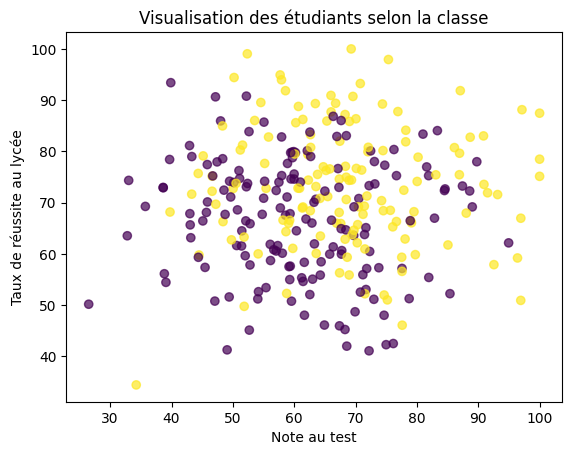

In [5]:
plt.scatter(df["note_test"], df["taux_lycee"], c=df["admission"], alpha=0.7)
plt.xlabel("Note au test")
plt.ylabel("Taux de réussite au lycée")
plt.title("Visualisation des étudiants selon la classe")
plt.show()

## 4. Séparation des variables explicatives et de la cible

La matrice `X` contient les variables explicatives. Le vecteur `y` contient la classe réelle : 0 pour non admis et 1 pour admis.

In [6]:
feature_names = ["note_test", "taux_lycee", "extrasco"]

X = df[feature_names].values
y = df["admission"].values

print("Forme de X :", X.shape)
print("Forme de y :", y.shape)

Forme de X : (300, 3)
Forme de y : (300,)


## 5. Séparation entre entraînement et test

Le modèle est entraîné sur 80 % des données et évalué sur les 20 % restants. Cette séparation est codée manuellement pour éviter l’utilisation d’une bibliothèque de machine learning.

In [7]:
def train_test_split_manual(X, y, test_size=0.2, random_state=42):
    """
    Sépare manuellement les données en ensemble d'entraînement et ensemble de test.

    Paramètres :
    X : numpy.ndarray
        Matrice des variables explicatives.
    y : numpy.ndarray
        Vecteur de la variable cible.
    test_size : float
        Proportion des données réservée au test.
    random_state : int
        Graine aléatoire utilisée pour mélanger les données.

    Retour :
    tuple
        X_train, X_test, y_train, y_test.
    """

    rng = np.random.default_rng(random_state)
    n_samples = X.shape[0]

    indices = np.arange(n_samples)
    rng.shuffle(indices)

    test_count = int(n_samples * test_size)
    test_indices = indices[:test_count]
    train_indices = indices[test_count:]

    X_train = X[train_indices]
    X_test = X[test_indices]
    y_train = y[train_indices]
    y_test = y[test_indices]

    return X_train, X_test, y_train, y_test


X_train, X_test, y_train, y_test = train_test_split_manual(X, y)

print("Nombre d'exemples d'entraînement :", X_train.shape[0])
print("Nombre d'exemples de test :", X_test.shape[0])

Nombre d'exemples d'entraînement : 240
Nombre d'exemples de test : 60


## 6. Normalisation des variables

Les variables `note_test` et `taux_lycee` sont normalisées pour qu’elles soient sur des échelles comparables. En revanche, la variable `extrasco` n’a pas besoin d’être normalisée, puisqu’elle vaut déjà seulement 0 ou 1.

La moyenne et l’écart-type sont calculés uniquement à partir des données d’entraînement. Ensuite, ces mêmes valeurs sont utilisées pour normaliser les données de test. Cela permet d’éviter que le modèle ait accès, même indirectement, à des informations provenant du test pendant l’entraînement.


In [8]:
def normalize_train_test(X_train, X_test, columns_to_normalize):
    """
    Normalise certaines colonnes des données à partir de la moyenne et de l'écart-type
    calculés uniquement sur l'ensemble d'entraînement.

    Paramètres :
    X_train : numpy.ndarray
        Données d'entraînement.
    X_test : numpy.ndarray
        Données de test.
    columns_to_normalize : list
        Indices des colonnes à normaliser.

    Retour :
    tuple
        Données d'entraînement normalisées, données de test normalisées,
        moyennes utilisées, écarts-types utilisés.
    """

    X_train_normalized = X_train.copy().astype(float)
    X_test_normalized = X_test.copy().astype(float)

    means = X_train_normalized[:, columns_to_normalize].mean(axis=0)
    stds = X_train_normalized[:, columns_to_normalize].std(axis=0)

    X_train_normalized[:, columns_to_normalize] = (
        X_train_normalized[:, columns_to_normalize] - means
    ) / stds

    X_test_normalized[:, columns_to_normalize] = (
        X_test_normalized[:, columns_to_normalize] - means
    ) / stds

    return X_train_normalized, X_test_normalized, means, stds


columns_to_normalize = [0, 1]

X_train_norm, X_test_norm, means, stds = normalize_train_test(
    X_train,
    X_test,
    columns_to_normalize
)

print("Moyennes utilisées :", means)
print("Écarts-types utilisés :", stds)

Moyennes utilisées : [64.02303338 69.55882443]
Écarts-types utilisés : [13.84324845 12.04755778]


## 7. Fonction sigmoïde

La régression logistique calcule d’abord une combinaison linéaire des variables. Cette valeur peut être négative ou positive. La fonction sigmoïde transforme ensuite cette valeur en une probabilité comprise entre 0 et 1.

La formule est :

\[
\sigma(z) = \frac{1}{1 + e^{-z}}
\]

In [9]:
def sigmoid(z):
    """
    Calcule la fonction sigmoïde.

    Paramètre :
    z : float ou numpy.ndarray
        Valeur ou tableau de valeurs à transformer.

    Retour :
    float ou numpy.ndarray
        Valeur comprise entre 0 et 1, interprétable comme une probabilité.
    """

    z = np.clip(z, -500, 500)
    return 1 / (1 + np.exp(-z))

## 8. Fonction de coût log-loss

La fonction de coût mesure l’erreur du modèle. Pour une classification binaire, on utilise la log-loss, aussi appelée entropie croisée binaire.

Plus la valeur de cette fonction est faible, meilleur est le modèle.

In [10]:
def compute_loss(y_true, y_pred):
    """
    Calcule la fonction de coût log-loss.

    Paramètres :
    y_true : numpy.ndarray
        Valeurs réelles de la classe, égales à 0 ou 1.
    y_pred : numpy.ndarray
        Probabilités prédites par le modèle.

    Retour :
    float
        Valeur moyenne de la perte.
    """

    epsilon = 1e-15
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)

    loss = -np.mean(
        y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred)
    )

    return loss

## 9. Entraînement par descente de gradient

La descente de gradient ajuste progressivement les poids du modèle afin de réduire la fonction de coût.

À chaque itération :

1. le modèle calcule une probabilité prédite ;
2. l’erreur est mesurée avec la log-loss ;
3. les gradients sont calculés ;
4. les poids et le biais sont mis à jour.

In [11]:
def train_logistic_regression(X, y, learning_rate=0.1, n_iterations=2000):
    """
    Entraîne un modèle de régression logistique avec la descente de gradient.

    Paramètres :
    X : numpy.ndarray
        Matrice des variables explicatives.
    y : numpy.ndarray
        Vecteur contenant les classes réelles.
    learning_rate : float
        Taux d'apprentissage utilisé pour mettre à jour les paramètres.
    n_iterations : int
        Nombre d'itérations de la descente de gradient.

    Retour :
    tuple
        weights : poids appris par le modèle.
        bias : biais appris par le modèle.
        losses : historique de la fonction de coût.
    """

    n_samples, n_features = X.shape

    weights = np.zeros(n_features)
    bias = 0.0
    losses = []

    for iteration in range(n_iterations):
        linear_model = np.dot(X, weights) + bias
        y_pred = sigmoid(linear_model)

        loss = compute_loss(y, y_pred)
        losses.append(loss)

        error = y_pred - y

        gradient_weights = np.dot(X.T, error) / n_samples
        gradient_bias = np.mean(error)

        weights = weights - learning_rate * gradient_weights
        bias = bias - learning_rate * gradient_bias

    return weights, bias, losses

## 10. Entraînement du modèle

Le modèle est entraîné avec 2000 itérations et un taux d’apprentissage égal à 0,1. Le temps d’entraînement est mesuré afin d’obtenir une information supplémentaire sur la performance de l’implémentation.

In [12]:
start_time = time.time()

weights, bias, losses = train_logistic_regression(
    X_train_norm,
    y_train,
    learning_rate=0.1,
    n_iterations=2000
)

end_time = time.time()
training_time = end_time - start_time

print("Poids appris :", weights)
print("Biais appris :", bias)
print("Temps d'entraînement :", round(training_time, 4), "seconde(s)")
print("Perte finale :", round(losses[-1], 4))

Poids appris : [0.55853298 0.50381782 0.22284535]
Biais appris : -0.34007495443977176
Temps d'entraînement : 0.3565 seconde(s)
Perte finale : 0.6275


## 11. Visualisation de la fonction de coût

La courbe suivante permet de vérifier que la log-loss diminue pendant l’entraînement. Une courbe décroissante indique que la descente de gradient fonctionne correctement.

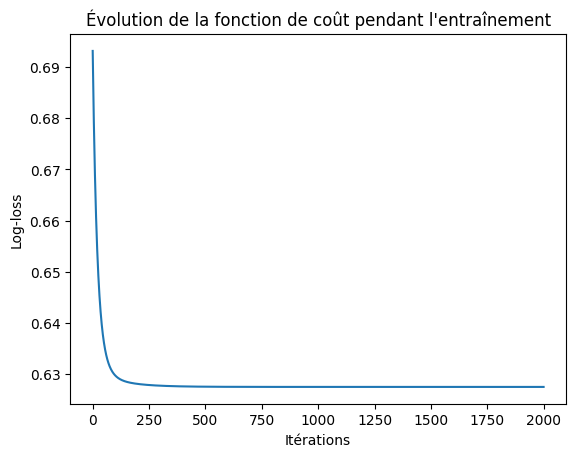

In [13]:
plt.plot(losses)
plt.xlabel("Itérations")
plt.ylabel("Log-loss")
plt.title("Évolution de la fonction de coût pendant l'entraînement")
plt.show()

## 12. Fonctions de prédiction

Le modèle produit d’abord une probabilité d’admission. Ensuite, cette probabilité est transformée en classe avec un seuil fixé à 0,5.

- Si la probabilité est supérieure ou égale à 0,5, la classe prédite est 1.
- Sinon, la classe prédite est 0.

In [14]:
def predict_proba(X, weights, bias):
    """
    Calcule les probabilités prédites par le modèle.

    Paramètres :
    X : numpy.ndarray
        Matrice des variables explicatives.
    weights : numpy.ndarray
        Poids appris par le modèle.
    bias : float
        Biais appris par le modèle.

    Retour :
    numpy.ndarray
        Probabilités prédites.
    """

    linear_model = np.dot(X, weights) + bias
    probabilities = sigmoid(linear_model)

    return probabilities


def predict(X, weights, bias, threshold=0.5):
    """
    Convertit les probabilités prédites en classes 0 ou 1.

    Paramètres :
    X : numpy.ndarray
        Matrice des variables explicatives.
    weights : numpy.ndarray
        Poids appris par le modèle.
    bias : float
        Biais appris par le modèle.
    threshold : float
        Seuil de décision utilisé pour convertir une probabilité en classe.

    Retour :
    numpy.ndarray
        Classes prédites, égales à 0 ou 1.
    """

    probabilities = predict_proba(X, weights, bias)
    classes = (probabilities >= threshold).astype(int)

    return classes

## 13. Métriques d’évaluation

Les métriques suivantes sont codées manuellement :

- matrice de confusion ;
- accuracy ;
- précision ;
- rappel ;
- F1-score.

Ces indicateurs permettent d’analyser plus finement les erreurs du modèle.

In [15]:
def confusion_matrix_manual(y_true, y_pred):
    """
    Calcule manuellement la matrice de confusion.

    Paramètres :
    y_true : numpy.ndarray
        Classes réelles.
    y_pred : numpy.ndarray
        Classes prédites.

    Retour :
    numpy.ndarray
        Matrice de confusion sous la forme :
        [[vrais négatifs, faux positifs],
         [faux négatifs, vrais positifs]]
    """

    true_negative = np.sum((y_true == 0) & (y_pred == 0))
    false_positive = np.sum((y_true == 0) & (y_pred == 1))
    false_negative = np.sum((y_true == 1) & (y_pred == 0))
    true_positive = np.sum((y_true == 1) & (y_pred == 1))

    return np.array([
        [true_negative, false_positive],
        [false_negative, true_positive]
    ])


def accuracy_score_manual(y_true, y_pred):
    """
    Calcule l'accuracy du modèle.

    Paramètres :
    y_true : numpy.ndarray
        Classes réelles.
    y_pred : numpy.ndarray
        Classes prédites.

    Retour :
    float
        Proportion totale de prédictions correctes.
    """

    return np.mean(y_true == y_pred)


def precision_score_manual(y_true, y_pred):
    """
    Calcule la précision pour la classe positive.

    Paramètres :
    y_true : numpy.ndarray
        Classes réelles.
    y_pred : numpy.ndarray
        Classes prédites.

    Retour :
    float
        Proportion de vrais positifs parmi les prédictions positives.
    """

    true_positive = np.sum((y_true == 1) & (y_pred == 1))
    false_positive = np.sum((y_true == 0) & (y_pred == 1))

    denominator = true_positive + false_positive

    if denominator == 0:
        return 0

    return true_positive / denominator


def recall_score_manual(y_true, y_pred):
    """
    Calcule le rappel pour la classe positive.

    Paramètres :
    y_true : numpy.ndarray
        Classes réelles.
    y_pred : numpy.ndarray
        Classes prédites.

    Retour :
    float
        Proportion de vrais positifs retrouvés parmi tous les exemples réellement positifs.
    """

    true_positive = np.sum((y_true == 1) & (y_pred == 1))
    false_negative = np.sum((y_true == 1) & (y_pred == 0))

    denominator = true_positive + false_negative

    if denominator == 0:
        return 0

    return true_positive / denominator


def f1_score_manual(y_true, y_pred):
    """
    Calcule le score F1.

    Paramètres :
    y_true : numpy.ndarray
        Classes réelles.
    y_pred : numpy.ndarray
        Classes prédites.

    Retour :
    float
        Moyenne harmonique entre la précision et le rappel.
    """

    precision = precision_score_manual(y_true, y_pred)
    recall = recall_score_manual(y_true, y_pred)

    denominator = precision + recall

    if denominator == 0:
        return 0

    return 2 * precision * recall / denominator

## 14. Résultats sur l’ensemble de test

Le modèle est évalué sur des données qu’il n’a pas utilisées pendant l’entraînement. Cela permet d’estimer sa capacité de généralisation.

In [16]:
y_test_proba = predict_proba(X_test_norm, weights, bias)
y_test_pred = predict(X_test_norm, weights, bias, threshold=0.5)

conf_matrix = confusion_matrix_manual(y_test, y_test_pred)
accuracy = accuracy_score_manual(y_test, y_test_pred)
precision = precision_score_manual(y_test, y_test_pred)
recall = recall_score_manual(y_test, y_test_pred)
f1 = f1_score_manual(y_test, y_test_pred)

print("Matrice de confusion :")
print(conf_matrix)

print("\nAccuracy :", round(accuracy, 4))
print("Précision :", round(precision, 4))
print("Rappel :", round(recall, 4))
print("F1-score :", round(f1, 4))

Matrice de confusion :
[[22  5]
 [ 8 25]]

Accuracy : 0.7833
Précision : 0.8333
Rappel : 0.7576
F1-score : 0.7937


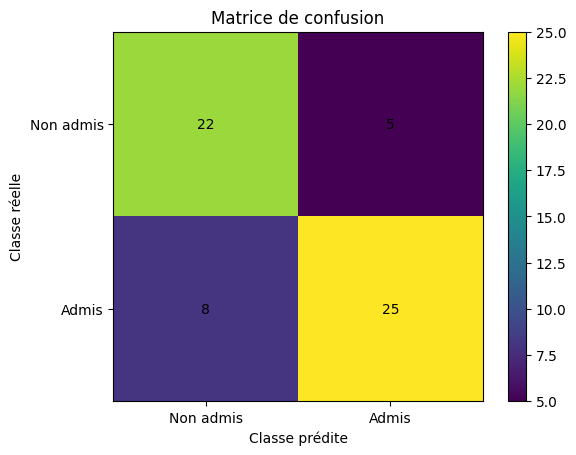

In [17]:
plt.imshow(conf_matrix)
plt.title("Matrice de confusion")
plt.xlabel("Classe prédite")
plt.ylabel("Classe réelle")
plt.xticks([0, 1], ["Non admis", "Admis"])
plt.yticks([0, 1], ["Non admis", "Admis"])

for i in range(conf_matrix.shape[0]):
    for j in range(conf_matrix.shape[1]):
        plt.text(j, i, conf_matrix[i, j], ha="center", va="center")

plt.colorbar()
plt.show()

## 15. Courbe ROC et AUC

La courbe ROC montre le compromis entre le taux de vrais positifs et le taux de faux positifs pour différents seuils de décision. L’AUC résume cette courbe en une seule valeur : plus elle est proche de 1, meilleure est la séparation entre les deux classes.

/tmp/ipykernel_8156/1823152566.py:55: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(tpr, fpr)


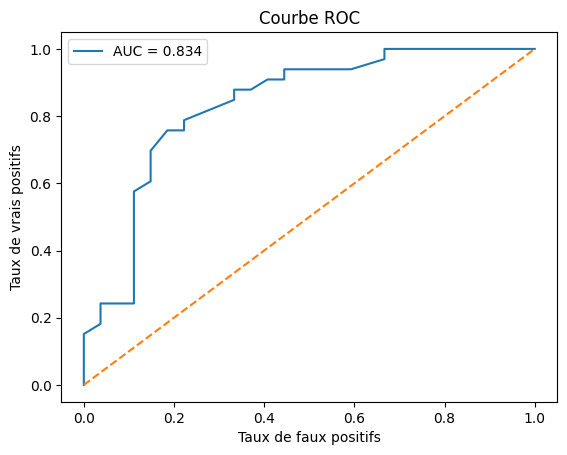

AUC : 0.8345


In [18]:
def roc_curve_manual(y_true, y_scores):
    """
    Calcule manuellement les points de la courbe ROC.

    Paramètres :
    y_true : numpy.ndarray
        Classes réelles.
    y_scores : numpy.ndarray
        Probabilités prédites pour la classe positive.

    Retour :
    tuple
        Taux de faux positifs, taux de vrais positifs, seuils utilisés.
    """

    thresholds = np.linspace(1, 0, 101)
    tpr_values = []
    fpr_values = []

    for threshold in thresholds:
        y_pred = (y_scores >= threshold).astype(int)
        matrix = confusion_matrix_manual(y_true, y_pred)

        true_negative = matrix[0, 0]
        false_positive = matrix[0, 1]
        false_negative = matrix[1, 0]
        true_positive = matrix[1, 1]

        tpr = 0 if true_positive + false_negative == 0 else true_positive / (true_positive + false_negative)
        fpr = 0 if false_positive + true_negative == 0 else false_positive / (false_positive + true_negative)

        tpr_values.append(tpr)
        fpr_values.append(fpr)

    order = np.argsort(fpr_values)

    return np.array(fpr_values)[order], np.array(tpr_values)[order], thresholds[order]


def auc_trapezoidal(fpr, tpr):
    """
    Calcule l'aire sous la courbe ROC avec la méthode des trapèzes.

    Paramètres :
    fpr : numpy.ndarray
        Taux de faux positifs.
    tpr : numpy.ndarray
        Taux de vrais positifs.

    Retour :
    float
        Aire sous la courbe ROC.
    """

    return np.trapz(tpr, fpr)


fpr, tpr, thresholds = roc_curve_manual(y_test, y_test_proba)
auc = auc_trapezoidal(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("Taux de faux positifs")
plt.ylabel("Taux de vrais positifs")
plt.title("Courbe ROC")
plt.legend()
plt.show()

print("AUC :", round(auc, 4))

## 16. Interprétation des coefficients

Les coefficients indiquent l’influence de chaque variable sur la probabilité d’admission.

- Un coefficient positif augmente la probabilité d’admission.
- Un coefficient négatif diminue la probabilité d’admission.
- Plus la valeur absolue du coefficient est grande, plus la variable a une influence importante.

,variable,coefficient,importance_absolue
0,note_test,0.558533,0.558533
1,taux_lycee,0.503818,0.503818
2,extrasco,0.222845,0.222845


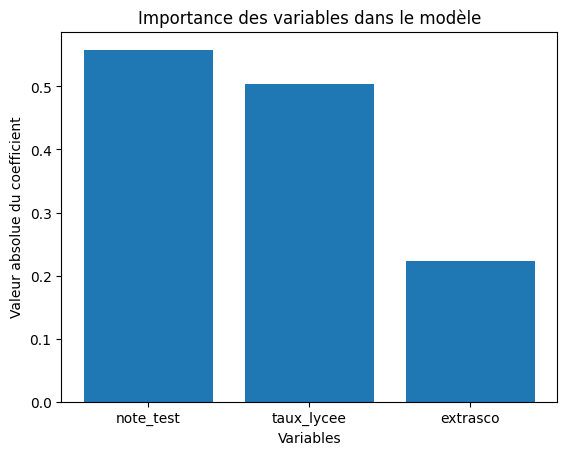

In [19]:
importance = np.abs(weights)

importance_df = pd.DataFrame({
    "variable": feature_names,
    "coefficient": weights,
    "importance_absolue": importance
})

importance_df = importance_df.sort_values(
    by="importance_absolue",
    ascending=False
)

display(importance_df)

plt.bar(importance_df["variable"], importance_df["importance_absolue"])
plt.xlabel("Variables")
plt.ylabel("Valeur absolue du coefficient")
plt.title("Importance des variables dans le modèle")
plt.show()

In [20]:
for variable, coefficient in zip(feature_names, weights):
    if coefficient > 0:
        effet = "augmente"
    elif coefficient < 0:
        effet = "diminue"
    else:
        effet = "n'a pas d'effet visible sur"

    print(
        f"La variable {variable} {effet} la probabilité d'admission "
        f"avec un coefficient de {coefficient:.4f}."
    )

La variable note_test augmente la probabilité d'admission avec un coefficient de 0.5585.
La variable taux_lycee augmente la probabilité d'admission avec un coefficient de 0.5038.
La variable extrasco augmente la probabilité d'admission avec un coefficient de 0.2228.


## 17. Limites du modèle

La régression logistique est un modèle assez simple à comprendre et à interpréter, mais elle a aussi certaines limites.

D’abord, elle fonctionne en supposant qu’il existe une relation plutôt linéaire entre les variables explicatives et le score qui sert à calculer la probabilité. Donc, si les relations entre les variables sont trop complexes, le modèle peut être moins précis.

Ensuite, dans ce projet, les données utilisées sont artificielles. Elles sont utiles pour comprendre le fonctionnement de l’algorithme, mais elles ne permettent pas de tirer de vraies conclusions sur un processus réel d’admission universitaire.

Enfin, le choix du seuil de décision, ici fixé à 0,5, a un effet direct sur les prédictions. Dans un cas réel, ce seuil pourrait être modifié en fonction de l’objectif recherché.
